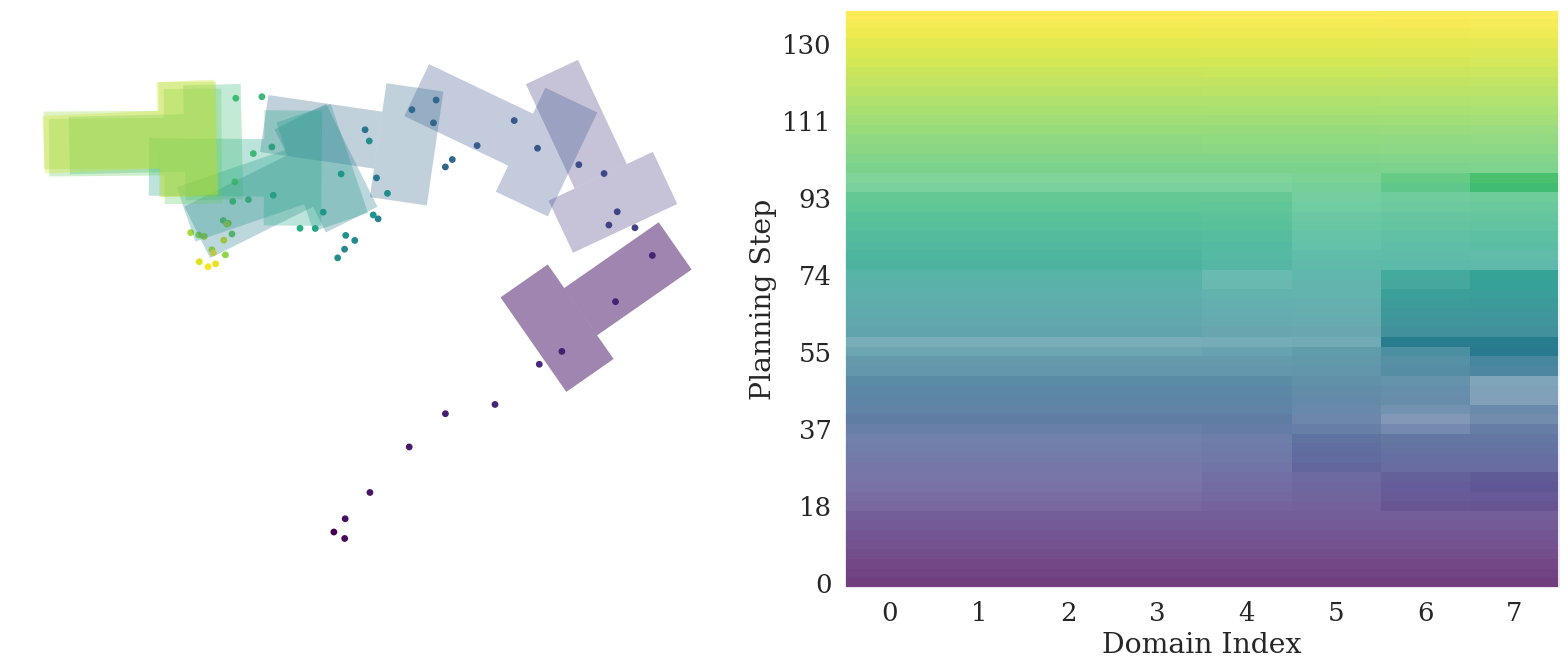

<Figure size 640x480 with 0 Axes>

In [1]:
import pickle
import math
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.patches import Rectangle, Polygon
from hydrax.utils.files import get_data_path, get_img_path, mkdir   
from hydrax.utils.plotting import get_yaw_from_quat, rotmat

# --- Setup Styling ---


sns.set_theme(font_scale=1.7,rc={
    "axes.facecolor": "white",   # inside axes
    "figure.facecolor": "white",  # outside axes
    'font.size':17,
    'font.family':'serif'
},)
img_path = get_img_path()


def t_shape_polys(x, y, yaw, stem_w=0.05, stem_h=0.1, head_w=0.1, head_h=0.05):
    """Calculates T-shape geometry for plotting."""
    offset = np.array([0.0425, 0.0])
    R_mat = rotmat(yaw)
    
    stem_center = (np.array([0.0, -head_h / 2.0]) @ R_mat.T) + np.array([x, y]) + offset
    head_center = (np.array([0.0,  stem_h / 2.0]) @ R_mat.T) + np.array([x, y]) + offset
    
    def get_corners(center, w, h):
        hw, hh = w/2, h/2
        local = np.array([[-hw, -hh], [hw, -hh], [hw, hh], [-hw, hh]])
        return (local @ R_mat.T) + center

    return get_corners(stem_center, stem_w, stem_h), get_corners(head_center, head_w, head_h)

def draw_t(ax, x, y, yaw, **kwargs):
    stem_poly, head_poly = t_shape_polys(x, y, yaw)
    ax.add_patch(Polygon(stem_poly, closed=True, **kwargs))
    ax.add_patch(Polygon(head_poly, closed=True, **kwargs))

# --- Data Loading and Processing ---

seeds = [100]
version = "exp"
target_steps = 80
cutoff_at_step = 60 

all_data = {}

for seed in seeds:
    path = get_data_path() / "dr_real_margin_shifting" / f"fr3_dr_real_MTP_seed{seed}_{version}.pkl"
    with open(path, "rb") as f:
        raw_data = pickle.load(f)
    
    # 1. Initial Subsampling
    indices = np.linspace(0, len(raw_data) - 1, min(len(raw_data), target_steps), dtype=int)
    subsampled = [raw_data[i] for i in indices]
    
    # 2. Apply Cutoff (If specified)
    if cutoff_at_step is not None:
        subsampled = subsampled[:cutoff_at_step]
    
    processed = {
        'poses': [],   
        'weights': [], 
        'ee_pos': []   
    }
    
    for d in subsampled:
        yaw = get_yaw_from_quat(d['object_quat'])
        processed['poses'].append([d['object_pos'][0], d['object_pos'][1], yaw])
        processed['weights'].append(d['domain_weights'])
        processed['ee_pos'].append(d['ee_pos'])
        
    all_data[seed] = processed

# --- Combined Visualization (Seed 100 example) ---

seed_to_plot = 100
data = all_data[seed_to_plot]
poses = np.array(data['poses'])
weights = np.array(data['weights'])
ee_pos = np.array(data['ee_pos'])
num_steps = len(poses)

# Define Colormap for Step
cmap = plt.cm.viridis
colors_step = cmap(np.linspace(0, 1, num_steps))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# 1. Trajectory Plot (Left)
# ax1.set_title(f"Trajectory (Seed {seed_to_plot} | Steps 0-{num_steps})")
ax1.scatter(ee_pos[:, 0], ee_pos[:, 1], c=colors_step, s=15, label='EE Path', zorder=5)

# Draw T-shapes at intervals
for i in range(0, num_steps, 5):
    # Applied your -pi/2 yaw correction
    draw_t(ax1, poses[i, 0], poses[i, 1], poses[i, 2] - np.pi / 2, 
           facecolor=colors_step[i], alpha=0.3, edgecolor='none', zorder=10)

ax1.set_aspect('equal')
sns.despine(ax=ax1)
ax1.grid(False)
ax1.set_yticks([])  
ax1.set_xticks([])  

# 2. Relationship Heatmap (Right)
num_domains = weights.shape[1]
rgba_matrix = np.zeros((num_steps, num_domains, 4))

for i in range(num_steps):
    rgba_matrix[i, :, :3] = colors_step[i, :3]
    rgba_matrix[i, :, 3] = np.clip(weights[i, :] ** 0.8 * 4, 0, 1)

ax2.imshow(rgba_matrix, aspect='auto', interpolation='nearest', origin='lower')
# ax2.set_title("Weights: Color (Step) & Alpha (Weight)")
# set y ticks accroding to indices
y_ticks = indices[::10]
ax2.set_yticks(np.arange(len(y_ticks))*8)
ax2.set_yticklabels(y_ticks)
ax2.set_xlabel("Domain Index")
ax2.set_ylabel("Planning Step")
ax2.grid(False)

plt.tight_layout()
plt.show()
mkdir(f"{img_path}/fr3/dr")
plt.savefig(f"{img_path}/fr3/dr/fr3_domain_weights_seed{seed_to_plot}_{version}.pdf", bbox_inches='tight')